# CESAR School - Pós-graduação em Open-RAN e tecnologias emergentes
# Aplicações de IA e ML em RIC - Trabalho final

Aluno: Luciano Augusto Campagnoli da Silva

# 1. Análise crítica e seleção do algoritmo

O artigo [1] avalia a aplicação de diferentes modelos de aprendizado de máquina para aplicações do RIC (*RAN Intelligent Controller*) sobre uma rede 5G hspedada na *Singapure University of Technology and Design* (SUTD). Os modelos são treinados sobre dados de *KPMs* coletados a partir de um dispositivo móvel Samsung Galaxy S22 Ultra movimentado pela universidade, compondo quatro conjuntos de dados com aproximadamente 2000 registros cada [2]. Eles foram submetidos a técnicas de pré-processamento amplamente usaedas, divididos em conjuntos de treino e teste  e treinados para algoritmos baseados em instâncias (uma instância apenas como entrada) e sequência (sequência de amostras como entrada do algoritmo).

Segundo os autores do artigo e os resultados nele obtidos, para a aplicação de manutenção preditiva (*PM-rApp*), os modelos baseados em sequência possuem desempenho melhor do que os baseados em instâncias. Destaca-se o modelo de redes neurais profundas, que apresentou acurácia de 99,1% e métricas de prcisão, revocação e F1 igualmente altas. Apesar de não possuir o menor tempo de inferência entre os baseados em sequêncai, ainda é mais veloz que os de floresta aleatória e LSTM em quatro e sete vezes, respectivamente.

Baseado nas análises e resultados do artigo, reealizar-se-á os procedimentos descritos no estudo para o treinamento dos modelos. Analisar-se-á, de forma mais especial, o DNN com entrada baseada em sequência, que obteve melhor resultado do estudo.




# 2. Fundamentação teórica.

Uma rede neural profunda (Deep Neural Network – DNN) é um modelo de aprendizado de máquina inspirado, de forma simplificada, no funcionamento de redes de neurônios biológicos. Ela é composta por uma camada de entrada, várias camadas ocultas e uma camada de saída. O termo "profunda" está relacionado à presença de várias camadas de processamento, que permitem à rede aprender representações cada vez mais complexas dos dados.

O funcionamento começa com a apresentação dos dados de entrada à rede. Cada neurônio recebe valores de entrada, combina esses valores utilizando pesos, adiciona um termo de ajuste chamado bias e aplica uma função de ativação ao resultado. Matematicamente, a saída de um neurônio pode ser representada por:

$$
y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
$$

em que $x_i$ representa cada valor de entrada, $w_i$ representa o peso associado a essa entrada, (b) é o bias, (n) é o número de entradas e $f(\cdot)$ é a função de ativação. O somatório representa a combinação ponderada das entradas realizada pelo neurônio.

Em uma rede profunda, a saída de uma camada serve como entrada para a camada seguinte. Para uma camada (l), essa operação pode ser generalizada como:

$$
a_j^{(l)} =
f\left(
\sum_{i=1}^{n}
w_{ji}^{(l)}a_i^{(l-1)}
+
b_j^{(l)}
\right)
$$

Dessa forma, diferentes camadas podem aprender diferentes níveis de representação dos dados. As primeiras camadas tendem a identificar características mais simples, enquanto camadas mais profundas podem combinar essas características para representar padrões mais complexos.

Quando a entrada é baseada em uma sequência, em vez de instâncias independentes, a rede recebe um conjunto ordenado de valores ($x_1$, $x_2$, $\ldots$, $x_T$), no qual cada elemento está relacionado à sua posição na sequência. Nesse cenário, a previsão pode depender não apenas dos valores individuais, mas também da relação entre os elementos ao longo da sequência. Arquiteturas como redes neurais recorrentes (RNNs), LSTM, GRU e *Transformers* são especialmente utilizadas para esse tipo de problema, pois conseguem modelar dependências entre diferentes posições da sequência. Uma representação simplificada pode ser expressa por:

$$
\mathbf{h}_t =
f\left(
W\mathbf{x}_t +
U\mathbf{h}_{t-1} +
\mathbf{b}
\right),
$$

em que $\mathbf{x}_t$ representa a entrada no instante ou posição (t), $\mathbf{h}_{t-1}$ representa informações obtidas anteriormente na sequência e $\mathbf{h}_t$ representa a nova representação calculada pela rede. Assim, diferentemente de uma abordagem baseada em instâncias independentes, a ordem dos dados passa a fazer parte do processo de aprendizado.

Durante o treinamento, a saída produzida pela rede é comparada com o resultado esperado por meio de uma função de perda, que mede o erro da previsão. Em seguida, o algoritmo de retropropagação (*backpropagation*) calcula como os pesos de cada neurônio contribuíram para esse erro. Um método de otimização, como a descida do gradiente, utiliza essas informações para ajustar os pesos e reduzir gradualmente o erro. Esse processo é repetido muitas vezes utilizando diferentes exemplos do conjunto de treinamento. Por exemplo, em uma rede neural profunda utilizada para reconhecimento de imagens, as primeiras camadas podem aprender características simples, como linhas e bordas. Camadas intermediárias podem combinar essas características para identificar formas e partes de objetos, enquanto as mais profundas podem utilizar essas informações para reconhecer objetos completos (como carros, pessoas ou animais). Já em uma aplicação baseada em sequência (como previsão de séries temporais ou processamento de linguagem) a rede pode utilizar informações de diferentes posições da sequência para produzir sua previsão.


# 3. Execução


Leitura dos *datasets*.

In [1]:
import pandas as pd

df_lvl4_allRRU = pd.read_csv("./dataset/Lvl4_AllRRUOn_Anomaly_label.csv")
df_lvl5_allRRU = pd.read_csv("./dataset/Lvl5_AllRRUOn_Anomaly_label.csv")
df_lvl5_one_RRU = pd.read_csv("./dataset/Lvl6_1RRUOn_Anomaly_label.csv")
df_lvl6_allRRU = pd.read_csv("./dataset/Lvl6_AllRRUOn_Anomaly_label.csv")


Exibe o *dataset* do quinto andar para todas as RRUs.

In [2]:
df_lvl5_allRRU

,Time,NR-ARFCN,PCI,_oid,RSRP,RSRQ,SINR,PDSCH_MCS,PUSCH_MCS,PDSCH PRBs,PUSCH PRBs,throughput_DL,C-RNTI,Corridor_tag,lab_anom,lab_bs,lab_inf,lab_1rr,Label
0,2022-10-04 16:20:37.802,628416,17,1350791784,-87.599998,-10.3,29.400000,23.0,14.0,128.0,4.0,254936103,14493,0,0,0,0,0,0
1,2022-10-04 16:20:38.339,628416,17,1350791784,-87.199997,-10.3,29.100000,24.0,15.0,129.0,4.0,254936103,14493,0,0,0,0,0,0
2,2022-10-04 16:20:38.834,628416,17,1350791784,-87.099998,-10.4,28.400000,25.0,15.0,128.0,4.0,254936103,14493,0,0,0,0,0,0
3,2022-10-04 16:20:39.351,628416,17,1350791784,-87.000000,-10.4,27.799999,26.0,15.0,128.0,4.0,254936103,14493,0,0,0,0,0,0
4,2022-10-04 16:20:39.883,628416,17,1350791784,-86.699997,-10.4,28.500000,27.0,15.0,128.0,4.0,162886179,14493,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026,2022-10-04 16:39:55.153,628416,17,1350791784,-99.400002,-12.1,2.600000,22.0,14.0,4.0,4.0,132838651,15965,1,1,0,1,0,10
2027,2022-10-04 16:39:55.661,628416,17,1350791784,-98.000000,-13.1,2.300000,23.0,13.0,8.0,4.0,132838651,15965,1,1,0,1,0,10
2028,2022-10-04 16:39:56.229,628416,17,1350791784,-97.199997,-12.0,6.600000,23.0,13.0,4.0,4.0,132838651,15965,1,1,0,1,0,10
2029,2022-10-04 16:39:56.780,628416,17,1350791784,-98.599998,-12.4,0.400000,23.0,13.0,4.0,4.0,132838651,15965,1,1,0,1,0,10


Remove valores nulos.

In [3]:
df_lvl4_allRRU = df_lvl4_allRRU.dropna()
df_lvl5_allRRU = df_lvl5_allRRU.dropna()
df_lvl5_one_RRU = df_lvl5_one_RRU.dropna()
df_lvl6_allRRU = df_lvl6_allRRU.dropna()

Verifica valores únicos em cada um dos *datasets* para o atributo alvo ("lab_1rr").

In [4]:
display(df_lvl4_allRRU["lab_1rr"].unique())
display(df_lvl5_allRRU["lab_1rr"].unique())
display(df_lvl5_one_RRU["lab_1rr"].unique())
display(df_lvl6_allRRU["lab_1rr"].unique())

array([0])

array([0])

array([1])

array([0])

Registra-se séries dos sete *KPMs* coletados em função de seus respectivos *timestamps* para o *dataset* do sexto andar, tal qual feito no artigo [1].

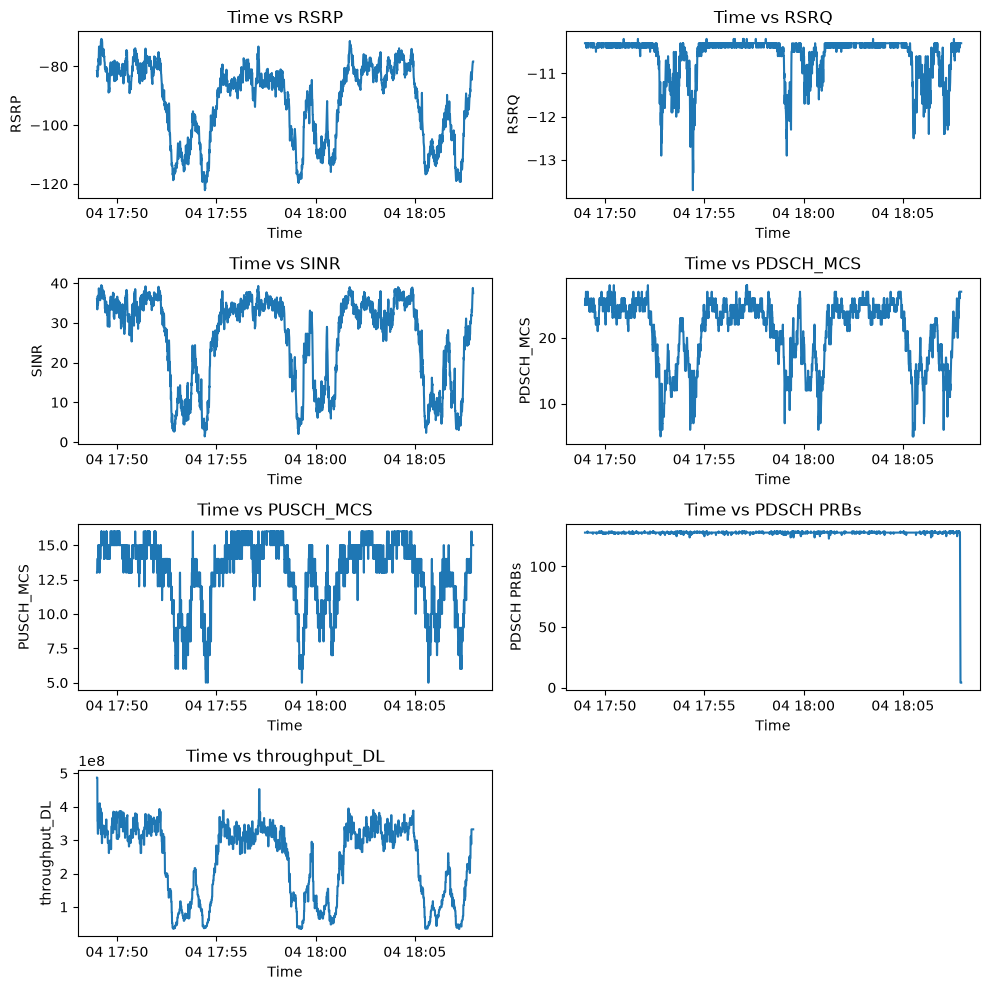

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'Time' in df_lvl6_allRRU.columns:
    df_lvl6_allRRU['Time'] = pd.to_datetime(df_lvl6_allRRU['Time'])

columns_to_plot = [
    "RSRP",
    "RSRQ",
    "SINR",
    "PDSCH_MCS",
    "PUSCH_MCS",
    "PDSCH PRBs",
    "throughput_DL"
]

plt.figure(figsize=(10, 10))
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(4, 2, i)
    sns.lineplot(data=df_lvl6_allRRU, x='Time', y=col)
    plt.title(f'Time vs {col}')
    plt.xlabel('Time')
    plt.ylabel(col)

plt.tight_layout()
plt.show()



Concatena-se os quatro *datasets* em um único.

In [6]:
df_concat = pd.concat([df_lvl4_allRRU, df_lvl5_allRRU, df_lvl5_one_RRU, df_lvl6_allRRU], ignore_index=True)
df_concat

,Time,NR-ARFCN,PCI,_oid,RSRP,RSRQ,SINR,PDSCH_MCS,PUSCH_MCS,PDSCH PRBs,PUSCH PRBs,throughput_DL,C-RNTI,Corridor_tag,lab_anom,lab_bs,lab_inf,lab_1rr,Label
0,2022-10-04 15:52:22.917,628416,17,1350791784,-107.199997,-10.5,17.100000,19.0,12.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
1,2022-10-04 15:52:23.435,628416,17,1350791784,-105.000000,-10.4,18.900000,19.0,13.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
2,2022-10-04 15:52:23.949,628416,17,1350791784,-101.400002,-10.4,20.500000,19.0,13.0,128.0,4.0,237685760,13853,0,0,0,0,0,0
3,2022-10-04 15:52:24.471,628416,17,1350791784,-102.199997,-10.3,18.900000,18.0,12.0,128.0,4.0,193200128,13853,0,0,0,0,0,0
4,2022-10-04 15:52:24.990,628416,17,1350791784,-102.099998,-10.3,21.000000,18.0,12.0,129.0,4.0,193200128,13853,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8622,2022-10-04 18:07:52.086000,628416,17,1350791784,-84.199997,-10.4,33.500000,26.0,15.0,128.0,6.0,332190720,16125,1,1,0,0,0,8
8623,2022-10-04 18:07:52.584000,628416,17,1350791784,-82.599998,-10.3,32.700001,27.0,15.0,127.0,5.0,332190720,16125,1,1,0,0,0,8
8624,2022-10-04 18:07:54.182000,628416,17,1350791784,-79.599998,-10.3,37.099998,27.0,15.0,4.0,4.0,332190720,16125,1,1,0,0,0,8
8625,2022-10-04 18:07:55.231000,628416,17,1350791784,-78.300003,-10.3,38.799999,27.0,15.0,4.0,4.0,332190720,16125,1,1,0,0,0,8


Gera-se a matriz de correlação das grandezas do *dataset*. Como pode se observar, não há grande correlação entre os sete KPMs, como mencionado em [1].

<module 'matplotlib.pyplot' from '/home/wsl/.pyenv/versions/3.11.9/lib/python3.11/site-packages/matplotlib/pyplot.py'>

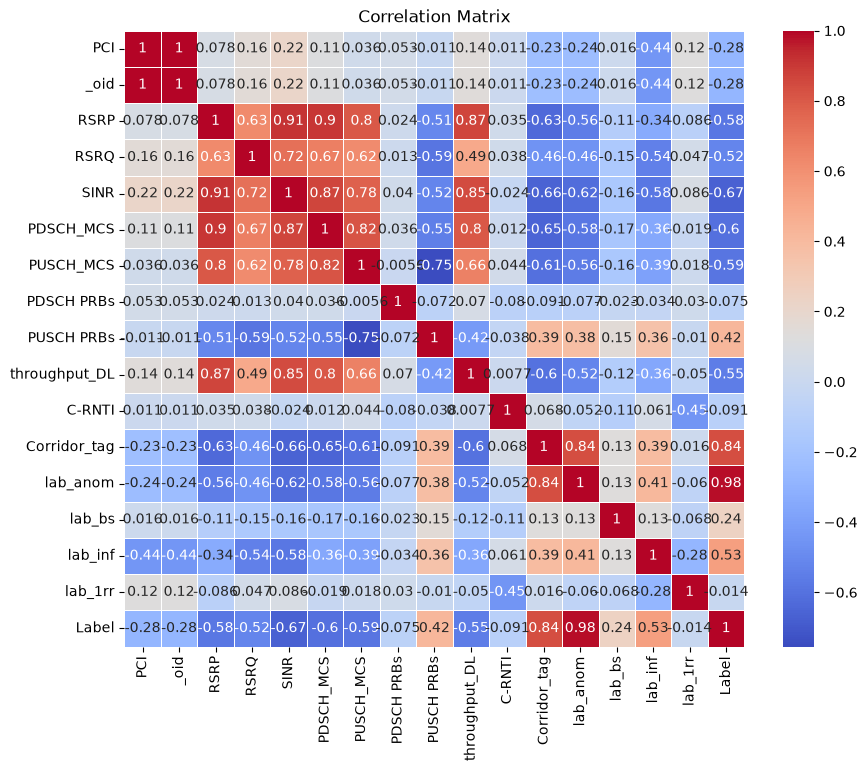

In [7]:
# Correlation matrix except 'Time' column
correlation_matrix = df_concat.drop(['Time', 'NR-ARFCN'], axis=1).corr()

# Create a heat map of 'correlation_matrix'
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix')
plt


In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_concat = df_concat.drop(['Time', 'NR-ARFCN'], axis=1)
df_concat_scaled = scaler.fit_transform(df_concat)

# Convert df_concat_scaled to Pandas dataframe
df_concat_scaled = pd.DataFrame(df_concat_scaled, columns=df_concat.columns)
df_concat_scaled

,PCI,_oid,RSRP,RSRQ,SINR,PDSCH_MCS,PUSCH_MCS,PDSCH PRBs,PUSCH PRBs,throughput_DL,C-RNTI,Corridor_tag,lab_anom,lab_bs,lab_inf,lab_1rr,Label
0,1.0,1.0,0.460972,0.985366,0.599284,0.678571,0.7500,0.992,0.000000,0.474842,0.098767,0.0,0.0,0.0,0.0,0.0,0.000000
1,1.0,1.0,0.493373,0.990244,0.631485,0.678571,0.8125,0.992,0.000000,0.474842,0.098767,0.0,0.0,0.0,0.0,0.0,0.000000
2,1.0,1.0,0.546392,0.990244,0.660107,0.678571,0.8125,0.992,0.000000,0.474842,0.098767,0.0,0.0,0.0,0.0,0.0,0.000000
3,1.0,1.0,0.534610,0.995122,0.631485,0.642857,0.7500,0.992,0.000000,0.385970,0.098767,0.0,0.0,0.0,0.0,0.0,0.000000
4,1.0,1.0,0.536082,0.995122,0.669052,0.642857,0.7500,1.000,0.000000,0.385970,0.098767,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8622,1.0,1.0,0.799705,0.990244,0.892665,0.928571,0.9375,0.992,0.044444,0.663641,0.114964,1.0,1.0,0.0,0.0,0.0,0.571429
8623,1.0,1.0,0.823270,0.995122,0.878354,0.964286,0.9375,0.984,0.022222,0.663641,0.114964,1.0,1.0,0.0,0.0,0.0,0.571429
8624,1.0,1.0,0.867452,0.995122,0.957066,0.964286,0.9375,0.000,0.000000,0.663641,0.114964,1.0,1.0,0.0,0.0,0.0,0.571429
8625,1.0,1.0,0.886598,0.995122,0.987478,0.964286,0.9375,0.000,0.000000,0.663641,0.114964,1.0,1.0,0.0,0.0,0.0,0.571429


## Treinamento de modelos baseados em instância

Divisão do conjunto de dados em conjunto de treino e teste, respeitando a proporção utilizada no estudo (70%/30%).

In [9]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_concat_scaled.drop('lab_1rr', axis=1), df_concat_scaled['lab_1rr'], test_size=0.3, random_state=42)


Criação, treinamento e inferência dos modelos com entradas baseadas em instâncias e medição dos tempos de inferência.

In [10]:
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import time

# Modelos
dnn = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=200, random_state=42, early_stopping=True, n_iter_no_change=10, validation_fraction=0.1)
linear_classifier = LogisticRegression(random_state=42, penalty='l2', C=0.1, solver='liblinear')
random_forest = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, min_samples_leaf=5)
svm = SVC(random_state=42, C=0.5, kernel='rbf')
xgboost = XGBClassifier(random_state=42, max_depth=3, reg_alpha=0.1, reg_lambda=0.1, n_estimators=100)

# Treinamento
dnn.fit(X_train, y_train)
linear_classifier.fit(X_train, y_train)
random_forest.fit(X_train, y_train)
svm.fit(X_train, y_train)
xgboost.fit(X_train, y_train)

# Inferência
start_time = time.time()
dnn_pred = dnn.predict(X_test)
end_time = time.time()
dnn_inference_time = end_time - start_time

start_time = time.time()
linear_classifier_pred = linear_classifier.predict(X_test)
end_time = time.time()
linear_classifier_inference_time = end_time - start_time

start_time = time.time()
random_forest_pred = random_forest.predict(X_test)
end_time = time.time()
random_forest_inference_time = end_time - start_time

start_time = time.time()
svm_pred = svm.predict(X_test)
end_time = time.time()
svm_inference_time = end_time - start_time

start_time = time.time()
xgboost_pred = xgboost.predict(X_test)
end_time = time.time()
xgboost_inference_time = end_time - start_time

print(f"DNN Inference Time: {dnn_inference_time:.4f} seconds")
print(f"Linear Classifier Inference Time: {linear_classifier_inference_time:.4f} seconds")
print(f"Random Forest Inference Time: {random_forest_inference_time:.4f} seconds")
print(f"SVM Inference Time: {svm_inference_time:.4f} seconds")
print(f"XGBoost Inference Time: {xgboost_inference_time:.4f} seconds")



/home/wsl/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


DNN Inference Time: 0.0315 seconds
Linear Classifier Inference Time: 0.0038 seconds
Random Forest Inference Time: 0.0336 seconds
SVM Inference Time: 0.2898 seconds
XGBoost Inference Time: 0.0699 seconds


Matriz comparativa.

In [11]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


results = pd.DataFrame({
    'Modelo': ['DNN', 'Linear Classifier', 'Random Forest', 'SVM', 'XGBoost'],
    'Acurácia': [accuracy_score(y_test, dnn_pred), accuracy_score(y_test, linear_classifier_pred), accuracy_score(y_test, random_forest_pred), accuracy_score(y_test, svm_pred), accuracy_score(y_test, xgboost_pred)],
    'Precisão': [precision_score(y_test, dnn_pred), precision_score(y_test, linear_classifier_pred), precision_score(y_test, random_forest_pred), precision_score(y_test, svm_pred), precision_score(y_test, xgboost_pred)],
    'Revocação': [recall_score(y_test, dnn_pred), recall_score(y_test, linear_classifier_pred), recall_score(y_test, random_forest_pred), recall_score(y_test, svm_pred), recall_score(y_test, xgboost_pred)],
    'F1': [f1_score(y_test, dnn_pred), f1_score(y_test, linear_classifier_pred), f1_score(y_test, random_forest_pred), f1_score(y_test, svm_pred), f1_score(y_test, xgboost_pred)],
    'Tempo de inferência': [dnn_inference_time, linear_classifier_inference_time, random_forest_inference_time, svm_inference_time, xgboost_inference_time]

})

results



,Modelo,Acurácia,Precisão,Revocação,F1,Tempo de inferência
0,DNN,0.999228,1.00000,0.996890,0.998442,0.031457
1,Linear Classifier,0.855543,0.99631,0.419907,0.590810,0.003781
2,Random Forest,0.999614,1.00000,0.998445,0.999222,0.033612
3,SVM,1.000000,1.00000,1.000000,1.000000,0.289810
4,XGBoost,1.000000,1.00000,1.000000,1.000000,0.069857


Matrizes de confusão.

In [12]:

cm_dnn = confusion_matrix(y_test, dnn_pred)
cm_linear_classifier = confusion_matrix(y_test, linear_classifier_pred)
cm_random_forest = confusion_matrix(y_test, random_forest_pred)
cm_svm = confusion_matrix(y_test, svm_pred)
cm_xgboost = confusion_matrix(y_test, xgboost_pred)

cm_dnn = pd.DataFrame(cm_dnn, columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])
cm_linear_classifier = pd.DataFrame(cm_linear_classifier, columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])
cm_random_forest = pd.DataFrame(cm_random_forest, columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])
cm_svm = pd.DataFrame(cm_svm, columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])
cm_xgboost = pd.DataFrame(cm_xgboost, columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])

display(cm_dnn)
display(cm_linear_classifier)
display(cm_random_forest)
display(cm_svm)
display(cm_xgboost)

#

,Predicted 0,Predicted 1
Actual 0,1946,0
Actual 1,2,641


,Predicted 0,Predicted 1
Actual 0,1945,1
Actual 1,373,270


,Predicted 0,Predicted 1
Actual 0,1946,0
Actual 1,1,642


,Predicted 0,Predicted 1
Actual 0,1946,0
Actual 1,0,643


,Predicted 0,Predicted 1
Actual 0,1946,0
Actual 1,0,643


## Treinamento de modelos baseados em sequências

### Preparação dos Dados para Modelos de Sequência

Para treinar modelos baseados em sequência, como LSTMs, precisamos transformar nossos dados de uma estrutura de `(amostras, características)` para `(amostras, timesteps, características)`. Cada `timestep` representa um ponto de dados em uma sequência, e a janela de `timesteps` será usada para prever o rótulo do último ponto na sequência. Neste exemplo, definiremos uma `n_steps` (duração da sequência) de 10.

In [13]:
import numpy as np

def create_sequences(data, labels, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        # Extract the sequence of features
        seq_x = data[i:(i + n_steps)]
        X.append(seq_x)

        # The label corresponds to the target at the end of the sequence
        seq_y = labels[i + n_steps]
        y.append(seq_y)
    return np.array(X), np.array(y)

# Assuming 'lab_1rr' is the target variable
features_scaled = df_concat_scaled.drop('lab_1rr', axis=1)
labels_scaled = df_concat_scaled['lab_1rr']

n_steps = 10  # Define the number of time steps in each sequence

X_seq, y_seq = create_sequences(features_scaled.values, labels_scaled.values, n_steps)

print(f"Shape of X_seq: {X_seq.shape}")
print(f"Shape of y_seq: {y_seq.shape}")

Shape of X_seq: (8617, 10, 16)
Shape of y_seq: (8617,)


### Divisão dos Dados em Conjuntos de Treinamento e Teste para Modelos de Sequência

Agora que os dados foram transformados em sequências, dividimos esses conjuntos de sequências em conjuntos de treinamento e teste.

In [14]:
from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, y_seq, test_size=0.3, random_state=42)

print(f"Shape of X_train_seq: {X_train_seq.shape}")
print(f"Shape of X_test_seq: {X_test_seq.shape}")
print(f"Shape of y_train_seq: {y_train_seq.shape}")
print(f"Shape of y_test_seq: {y_test_seq.shape}")

Shape of X_train_seq: (6031, 10, 16)
Shape of X_test_seq: (2586, 10, 16)
Shape of y_train_seq: (6031,)
Shape of y_test_seq: (2586,)


### Construção e Treinamento de um Modelo LSTM

Vamos usar uma Rede Neural de Memória de Longo Prazo (LSTM) como um exemplo de modelo baseado em sequência. As LSTMs são bem adequadas para dados de séries temporais devido à sua capacidade de aprender dependências de longo prazo.

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the LSTM model
model_lstm = Sequential([
    LSTM(units=50, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2), # Add dropout for regularization
    Dense(units=1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_lstm = model_lstm.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, validation_split=0.2, verbose=1)


I0000 00:00:1785635742.722273   19192 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785635742.888384   19192 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785635746.466056   19192 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
E0000 00:00:1785635747.019572   19192 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN

Epoch 1/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7904 - loss: 0.4310 - val_accuracy: 0.9843 - val_loss: 0.0911
Epoch 2/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9832 - loss: 0.0621 - val_accuracy: 0.9892 - val_loss: 0.0430
Epoch 3/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9959 - loss: 0.0188 - val_accuracy: 0.9992 - val_loss: 0.0049
Epoch 4/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9981 - loss: 0.0069 - val_accuracy: 0.9992 - val_loss: 0.0036
Epoch 5/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9977 - loss: 0.0082 - val_accuracy: 0.9992 - val_loss: 0.0053
Epoch 6/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9985 - loss: 0.0066 - val_accuracy: 0.9992 - val_loss: 0.0049
Epoch 7/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9992 - loss: 0.0039 - val_accuracy: 0.9992 - val_loss: 0.0016
Epoch 8/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9988 - loss: 0.0041 - val_accura

### Avaliação do Modelo LSTM

Após o treinamento, avaliaremos o desempenho do modelo LSTM no conjunto de teste.

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set
start_time = time.time()
y_pred_lstm_prob = model_lstm.predict(X_test_seq)
end_time = time.time()
lstm_inference_time = end_time - start_time
print(f"LSTM Inference Time: {lstm_inference_time:.4f} seconds")

y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int)

# Evaluate the LSTM model
accuracy_lstm = accuracy_score(y_test_seq, y_pred_lstm)
precision_lstm = precision_score(y_test_seq, y_pred_lstm)
recall_lstm = recall_score(y_test_seq, y_pred_lstm)
f1_lstm = f1_score(y_test_seq, y_pred_lstm)
cm_lstm = confusion_matrix(y_test_seq, y_pred_lstm)

print(f"LSTM Accuracy: {accuracy_lstm:.4f}")
print(f"LSTM Precision: {precision_lstm:.4f}")
print(f"LSTM Recall: {recall_lstm:.4f}")
print(f"LSTM F1-Score: {f1_lstm:.4f}")
print("LSTM Confusion Matrix:")
print(cm_lstm)

# Display as a DataFrame for consistency with previous results
cm_lstm_df = pd.DataFrame(cm_lstm, columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])
display(cm_lstm_df)

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
LSTM Inference Time: 0.7321 seconds
LSTM Accuracy: 0.9985
LSTM Precision: 0.9969
LSTM Recall: 0.9969
LSTM F1-Score: 0.9969
LSTM Confusion Matrix:
[[1941    2]
 [   2  641]]


,Predicted 0,Predicted 1
Actual 0,1941,2
Actual 1,2,641


### Preparação dos Dados de Sequência para Modelos Tradicionais

Modelos como DNN (MLPClassifier), Regressão Logística, Random Forest e XGBoost esperam entradas 2D (`(amostras, características)`), enquanto nossos dados de sequência estão em 3D (`(amostras, timesteps, características)`). Portanto, precisamos achatar (flatten) os dados de sequência para `(amostras, timesteps * características)` antes de alimentá-los a esses modelos.

In [17]:
# Flatten the sequence data for traditional models
num_samples_train = X_train_seq.shape[0]
num_timesteps = X_train_seq.shape[1]
num_features = X_train_seq.shape[2]

X_train_seq_flat = X_train_seq.reshape(num_samples_train, num_timesteps * num_features)

num_samples_test = X_test_seq.shape[0]
X_test_seq_flat = X_test_seq.reshape(num_samples_test, num_timesteps * num_features)

print(f"Shape of flattened X_train_seq: {X_train_seq_flat.shape}")
print(f"Shape of flattened X_test_seq: {X_test_seq_flat.shape}")

Shape of flattened X_train_seq: (6031, 160)
Shape of flattened X_test_seq: (2586, 160)


### Treinamento e Avaliação do Modelo DNN (MLPClassifier) com Dados de Sequência Achados

Agora, treinaremos e avaliaremos o modelo DNN usando os dados de sequência achatados.

In [18]:
from sklearn.neural_network import MLPClassifier

# Define o modelo DNN com dados achatados
dnn_seq = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=200, random_state=42, early_stopping=True, n_iter_no_change=10, validation_fraction=0.1)

# Treina o modelo
dnn_seq.fit(X_train_seq_flat, y_train_seq)

# Faz previsões
start_time = time.time()
dnn_seq_pred = dnn_seq.predict(X_test_seq_flat)
end_time = time.time()
dnn_seq_inference_time = end_time - start_time

print(f"DNN (Sequence) Inference Time: {dnn_seq_inference_time:.4f} seconds")

# Avalia o modelo
accuracy_dnn_seq = accuracy_score(y_test_seq, dnn_seq_pred)
precision_dnn_seq = precision_score(y_test_seq, dnn_seq_pred)
recall_dnn_seq = recall_score(y_test_seq, dnn_seq_pred)
f1_dnn_seq = f1_score(y_test_seq, dnn_seq_pred)
cm_dnn_seq = confusion_matrix(y_test_seq, dnn_seq_pred)

print(f"DNN (Sequence) Accuracy: {accuracy_dnn_seq:.4f}")
print(f"DNN (Sequence) Precision: {precision_dnn_seq:.4f}")
print(f"DNN (Sequence) Recall: {recall_dnn_seq:.4f}")
print(f"DNN (Sequence) F1-Score: {f1_dnn_seq:.4f}")
print("DNN (Sequence) Confusion Matrix:")
print(cm_dnn_seq)

cm_dnn_seq_df = pd.DataFrame(cm_dnn_seq, columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])
display(cm_dnn_seq_df)

DNN (Sequence) Inference Time: 0.0177 seconds
DNN (Sequence) Accuracy: 0.9973
DNN (Sequence) Precision: 0.9969
DNN (Sequence) Recall: 0.9922
DNN (Sequence) F1-Score: 0.9945
DNN (Sequence) Confusion Matrix:
[[1941    2]
 [   5  638]]


,Predicted 0,Predicted 1
Actual 0,1941,2
Actual 1,5,638


### Treinamento e Avaliação do Modelo de Regressão Logística com Dados de Sequência Achados

Agora, treinaremos e avaliaremos o modelo de Regressão Logística usando os dados de sequência achatados.

In [19]:
from sklearn.linear_model import LogisticRegression

# Define o modelo de Regressão Logística com dados achatados
linear_classifier_seq = LogisticRegression(random_state=42, penalty='l2', C=0.1, solver='liblinear')

# Treina o modelo
linear_classifier_seq.fit(X_train_seq_flat, y_train_seq)

# Faz previsões
start_time = time.time()
linear_classifier_seq_pred = linear_classifier_seq.predict(X_test_seq_flat)
end_time = time.time()
linear_classifier_seq_inference_time = end_time - start_time

print(f"Linear Classifier (Sequence) Inference Time: {linear_classifier_seq_inference_time:.4f} seconds")

# Avalia o modelo
accuracy_lc_seq = accuracy_score(y_test_seq, linear_classifier_seq_pred)
precision_lc_seq = precision_score(y_test_seq, linear_classifier_seq_pred)
recall_lc_seq = recall_score(y_test_seq, linear_classifier_seq_pred)
f1_lc_seq = f1_score(y_test_seq, linear_classifier_seq_pred)
cm_lc_seq = confusion_matrix(y_test_seq, linear_classifier_seq_pred)

print(f"Linear Classifier (Sequence) Accuracy: {accuracy_lc_seq:.4f}")
print(f"Linear Classifier (Sequence) Precision: {precision_lc_seq:.4f}")
print(f"Linear Classifier (Sequence) Recall: {recall_lc_seq:.4f}")
print(f"Linear Classifier (Sequence) F1-Score: {f1_lc_seq:.4f}")
print("Linear Classifier (Sequence) Confusion Matrix:")
print(cm_lc_seq)

cm_lc_seq_df = pd.DataFrame(cm_lc_seq, columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])
display(cm_lc_seq_df)

/home/wsl/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Linear Classifier (Sequence) Inference Time: 0.0011 seconds
Linear Classifier (Sequence) Accuracy: 0.9985
Linear Classifier (Sequence) Precision: 0.9969
Linear Classifier (Sequence) Recall: 0.9969
Linear Classifier (Sequence) F1-Score: 0.9969
Linear Classifier (Sequence) Confusion Matrix:
[[1941    2]
 [   2  641]]


,Predicted 0,Predicted 1
Actual 0,1941,2
Actual 1,2,641


### Treinamento e Avaliação do Modelo Random Forest com Dados de Sequência Achados

Agora, treinaremos e avaliaremos o modelo Random Forest usando os dados de sequência achatados.

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Define o modelo Random Forest com dados achatados
random_forest_seq = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, min_samples_leaf=5)

# Treina o modelo
random_forest_seq.fit(X_train_seq_flat, y_train_seq)

# Faz previsões
start_time = time.time()
random_forest_seq_pred = random_forest_seq.predict(X_test_seq_flat)
end_time = time.time()
random_forest_seq_inference_time = end_time - start_time

print(f"Random Forest (Sequence) Inference Time: {random_forest_seq_inference_time:.4f} seconds")

# Avalia o modelo
accuracy_rf_seq = accuracy_score(y_test_seq, random_forest_seq_pred)
precision_rf_seq = precision_score(y_test_seq, random_forest_seq_pred)
recall_rf_seq = recall_score(y_test_seq, random_forest_seq_pred)
f1_rf_seq = f1_score(y_test_seq, random_forest_seq_pred)
cm_rf_seq = confusion_matrix(y_test_seq, random_forest_seq_pred)

print(f"Random Forest (Sequence) Accuracy: {accuracy_rf_seq:.4f}")
print(f"Random Forest (Sequence) Precision: {precision_rf_seq:.4f}")
print(f"Random Forest (Sequence) Recall: {recall_rf_seq:.4f}")
print(f"Random Forest (Sequence) F1-Score: {f1_rf_seq:.4f}")
print("Random Forest (Sequence) Confusion Matrix:")
print(cm_rf_seq)

cm_rf_seq_df = pd.DataFrame(cm_rf_seq, columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])
display(cm_rf_seq_df)

Random Forest (Sequence) Inference Time: 0.0139 seconds
Random Forest (Sequence) Accuracy: 0.9988
Random Forest (Sequence) Precision: 0.9984
Random Forest (Sequence) Recall: 0.9969
Random Forest (Sequence) F1-Score: 0.9977
Random Forest (Sequence) Confusion Matrix:
[[1942    1]
 [   2  641]]


,Predicted 0,Predicted 1
Actual 0,1942,1
Actual 1,2,641


### Treinamento e Avaliação do Modelo XGBoost com Dados de Sequência Achados

Por fim, treinaremos e avaliaremos o modelo XGBoost usando os dados de sequência achatados.

In [21]:
from xgboost import XGBClassifier

# Define o modelo XGBoost com dados achatados
xgboost_seq = XGBClassifier(random_state=42, max_depth=3, reg_alpha=0.1, reg_lambda=0.1, n_estimators=100)

# Treina o modelo
xgboost_seq.fit(X_train_seq_flat, y_train_seq)

# Faz previsões
start_time = time.time()
xgboost_seq_pred = xgboost_seq.predict(X_test_seq_flat)
end_time = time.time()
xgboost_seq_inference_time = end_time - start_time

print(f"XGBoost (Sequence) Inference Time: {xgboost_seq_inference_time:.4f} seconds")

# Avalia o modelo
accuracy_xgb_seq = accuracy_score(y_test_seq, xgboost_seq_pred)
precision_xgb_seq = precision_score(y_test_seq, xgboost_seq_pred)
recall_xgb_seq = recall_score(y_test_seq, xgboost_seq_pred)
f1_xgb_seq = f1_score(y_test_seq, xgboost_seq_pred)
cm_xgb_seq = confusion_matrix(y_test_seq, xgboost_seq_pred)

print(f"XGBoost (Sequence) Accuracy: {accuracy_xgb_seq:.4f}")
print(f"XGBoost (Sequence) Precision: {precision_xgb_seq:.4f}")
print(f"XGBoost (Sequence) Recall: {recall_xgb_seq:.4f}")
print(f"XGBoost (Sequence) F1-Score: {f1_xgb_seq:.4f}")
print("XGBoost (Sequence) Confusion Matrix:")
print(cm_xgb_seq)

cm_xgb_seq_df = pd.DataFrame(cm_xgb_seq, columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])
display(cm_xgb_seq_df)

XGBoost (Sequence) Inference Time: 0.0049 seconds
XGBoost (Sequence) Accuracy: 0.9992
XGBoost (Sequence) Precision: 0.9984
XGBoost (Sequence) Recall: 0.9984
XGBoost (Sequence) F1-Score: 0.9984
XGBoost (Sequence) Confusion Matrix:
[[1942    1]
 [   1  642]]


,Predicted 0,Predicted 1
Actual 0,1942,1
Actual 1,1,642


### Resumo dos Resultados dos Modelos Baseados em Sequência (Achados)

In [22]:
from tensorflow.keras.layers import GRU

# Define the GRU model
model_gru = Sequential([
    GRU(units=50, activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    Dense(units=1, activation='sigmoid')
])

# Compile the model
model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_gru = model_gru.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/10


/home/wsl/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


151/151 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7548 - loss: 0.5125 - val_accuracy: 0.7490 - val_loss: 0.3739
Epoch 2/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9625 - loss: 0.1418 - val_accuracy: 0.9992 - val_loss: 0.0093
Epoch 3/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9946 - loss: 0.0331 - val_accuracy: 0.9992 - val_loss: 0.0073
Epoch 4/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9967 - loss: 0.0252 - val_accuracy: 0.9992 - val_loss: 0.0146
Epoch 5/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9971 - loss: 0.0195 - val_accuracy: 0.9992 - val_loss: 0.0078
Epoch 6/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9946 - loss: 0.0275 - val_accuracy: 0.9992 - val_loss: 0.0049
Epoch 7/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9977 - loss: 0.0137 - val_accuracy: 0.9992 - val_loss: 0.0058
Epoch 8/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9967 - loss: 0.0147 - val_accuracy: 0.999

In [23]:
# Agrega os resultados de todos os modelos de sequência
results_seq = pd.DataFrame({
    'Model': ['LSTM', 'DNN (Seq Flat)', 'Linear Classifier (Seq Flat)', 'Random Forest (Seq Flat)', 'XGBoost (Seq Flat)'],
    'Accuracy': [accuracy_lstm,  accuracy_dnn_seq, accuracy_lc_seq, accuracy_rf_seq, accuracy_xgb_seq],
    'Precision': [precision_lstm,  precision_dnn_seq, precision_lc_seq, precision_rf_seq, precision_xgb_seq],
    'Recall': [recall_lstm, recall_dnn_seq, recall_lc_seq, recall_rf_seq, recall_xgb_seq],
    'F1 Score': [f1_lstm, f1_dnn_seq, f1_lc_seq, f1_rf_seq, f1_xgb_seq],
    'Tempo de inferência': [lstm_inference_time, dnn_seq_inference_time, linear_classifier_seq_inference_time, random_forest_seq_inference_time, xgboost_seq_inference_time]
})

display(results_seq)

,Model,Accuracy,Precision,Recall,F1 Score,Tempo de inferência
0,LSTM,0.998453,0.996890,0.996890,0.996890,0.732070
1,DNN (Seq Flat),0.997293,0.996875,0.992224,0.994544,0.017655
2,Linear Classifier (Seq Flat),0.998453,0.996890,0.996890,0.996890,0.001079
3,Random Forest (Seq Flat),0.998840,0.998442,0.996890,0.997665,0.013942
4,XGBoost (Seq Flat),0.999227,0.998445,0.998445,0.998445,0.004884


# 4. Análises

Ao executar novamente os treinamentos descritos no estudo, percebe-se que o modelo DNN possui desempenho eficiente tanto na classificação com entradas instanciais como na com elas em sequências. No segundo caso, a acurácia, por exemplo, aproxima-se dos 99,7%, pouco superior ao do treinado em [1] (ligeira diferença que pode se explicar pela escolha dos hiperparâmetros). Entretanto, apesar da alta *performance*, os outros algoritmos baseados em sequência o superam ligeiramente nas outras métricas (precisão, revocação e F1). 

Quanto ao tempo de inferência, o DNN apresenta desempenho consideravelmente melhor que o LSTM (tempo de execução cerca de 70 vezes menor), mas equiparável ao da floresta aleatória (0,017 s contra 0,014 s), diferença que possivelmente também se explica pelo ajuste de hiperparâmetros. Como observado em [1], a inferência para todos os casos, baseados em amostras ou sequências, dura sempre menos de 1 s, o que permite enquadrá-los como *rApps* no contexto da Open RAN.




# 5. Referências
[1] Mao V. Ngo, Nguyen-Bao-Long Tran, Hyun-Min Yoo, Yong-Hao Pua, Thanh-Long Le, Xian-Loong Liang, Binbin Chen, Een-Kee Hong, Tony Q.S. Quek. RAN Intelligent Controller (RIC): From open-source implementation to real-world validation. ICT Express, Volume 10, Issue 3, 2024, Pages 680-691. ISSN 2405-9595. Disponível em:  https://doi.org/10.1016/j.icte.2024.02.001.

[2] FCCLAB. *SUTD 5G Dataset 2023*. GitHub, 2023. Disponível em: https://github.com/FCCLab/sutd_5g_dataset_2023/tree/dataset.
